In [1]:
# ============================================================
# Notebook setup: run this before everything
# ============================================================

%load_ext autoreload
%autoreload 2

# Control figure size
figsize=(14, 4)


from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from util import util
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import os

# Load data
data_folder = os.path.join('..', 'data', 'nab')
file_name = os.path.join('realKnownCause', 'nyc_taxi.csv')
data, labels, windows = util.load_series(file_name, data_folder)

# Train and validation end
train_end = pd.to_datetime('2014-10-24 00:00:00')
val_end = pd.to_datetime('2014-12-10 00:00:00')

# Cost model parameters
c_alrm = 1 # Cost of investigating a false alarm
c_missed = 10 # Cost of missing an anomaly
c_late = 5 # Cost for late detection

# Build a cost model
cmodel = util.ADSimpleCostModel(c_alrm, c_missed, c_late)

# Separate the training data
data_tr = data[data.index < train_end]

# Apply a sliding window
wdata = util.sliding_window_1D(data, wlen=48)

# A Time-Dependent Estimator

## Spotting the Problem

**The sequence-based estimator we built learns from all the training data**

This means it will learn from both these series, for example:

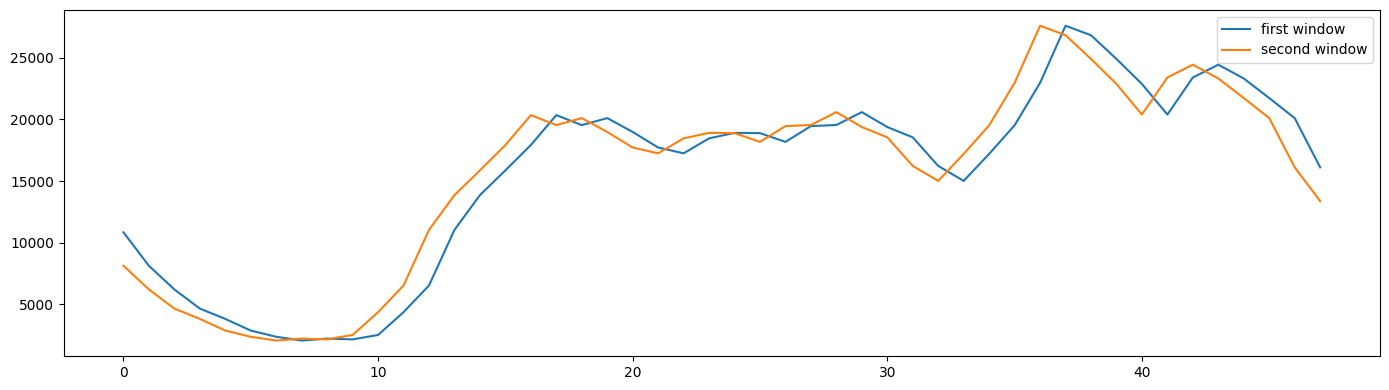

In [2]:
plt.figure(figsize=figsize)
plt.plot(wdata.iloc[0], label='first window')
plt.plot(wdata.iloc[1], label='second window')
plt.legend()
plt.tight_layout()

# Kernel Density Estimation (KDE)

Kernel Density Estimation (KDE) is a non-parametric method used to estimate the probability density function (PDF) of a random variable. It is particularly useful when we want to understand the underlying distribution of data without assuming a specific parametric form (e.g., Gaussian, Poisson).

## How KDE Works

KDE works by placing a kernel function (e.g., Gaussian, Epanechnikov) on each data point in the dataset. The kernel is a smooth, symmetric function that determines how much influence each data point has on the estimated density at a given location. The contributions of all kernels are summed to produce the final density estimate.

### Univariate KDE

In the univariate case, KDE learns a single probability density function for the entire dataset. This means that the KDE model estimates the likelihood of observing a specific scalar value $x$ by summing the contributions of all kernels centered at each data point. 

While it is true that a kernel is placed on each data point, the result of summing all these kernels is a single, continuous density function that represents the overall distribution of the data. This density function is what we refer to as the "single probability density function" for the dataset.

Mathematically, the univariate KDE is defined as:

$$
\hat{f}(x) = \frac{1}{n h} \sum_{i=1}^n K\left(\frac{x - x_i}{h}\right)
$$

Where:
- $n$ is the number of data points.
- $h$ is the bandwidth, which controls the smoothness of the density estimate.
- $K$ is the kernel function (e.g., Gaussian kernel).
- $x_i$ are the data points.

The bandwidth $h$ is a critical parameter in KDE. A small $h$ results in a very spiky density estimate, while a large $h$ produces an overly smooth estimate. Choosing the right bandwidth is crucial for obtaining a good density estimate.

## Multivariate KDE (Sliding Windows and Temporal Correlation)

In the multivariate case, KDE extends to estimate the joint probability density function of multiple variables. Instead of scalar values, the data points are vectors, and the kernel function is applied to these vectors. The multivariate KDE is defined as:

$$
\hat{f}(\mathbf{x}) = \frac{1}{n} \sum_{i=1}^n \frac{1}{h^d} K\left(\frac{\mathbf{x} - \mathbf{x}_i}{h}\right)
$$

Where:
- $\mathbf{x}$ is a vector of observations.
- $d$ is the dimensionality of the data.
- $K$ is a multivariate kernel function (e.g., multivariate Gaussian).

The multivariate KDE learns a single joint density function for the entire dataset, which represents the likelihood of observing a specific vector $\mathbf{x}$.

In time series data, observations are often correlated with their neighbors. To capture this temporal correlation, we can use a sliding window approach. This involves creating sequences of observations by sliding a fixed-size window over the time series data.

For example, consider a time series $x_0, x_1, x_2, \dots$. With a window size of 3, we can create the following sequences:
- First window: $[x_0, x_1, x_2]$
- Second window: $[x_1, x_2, x_3]$
- Third window: $[x_2, x_3, x_4]$

Each window is treated as a vector, and we can use multivariate KDE to estimate the joint distribution of the observations within each window. This allows us to detect anomalies based on the likelihood of observing a particular sequence of values.

However, this approach introduces a **challenge: the same observation (e.g., $x_0$) appears in multiple windows, but in different positions. This means the KDE model learns the distribution of $x_0$ multiple times, which increases the complexity of the learning problem and introduces noise into the alarm signal.**

## Rewind a Little

**Remember _why_ we introduced the sequence based estimator?**

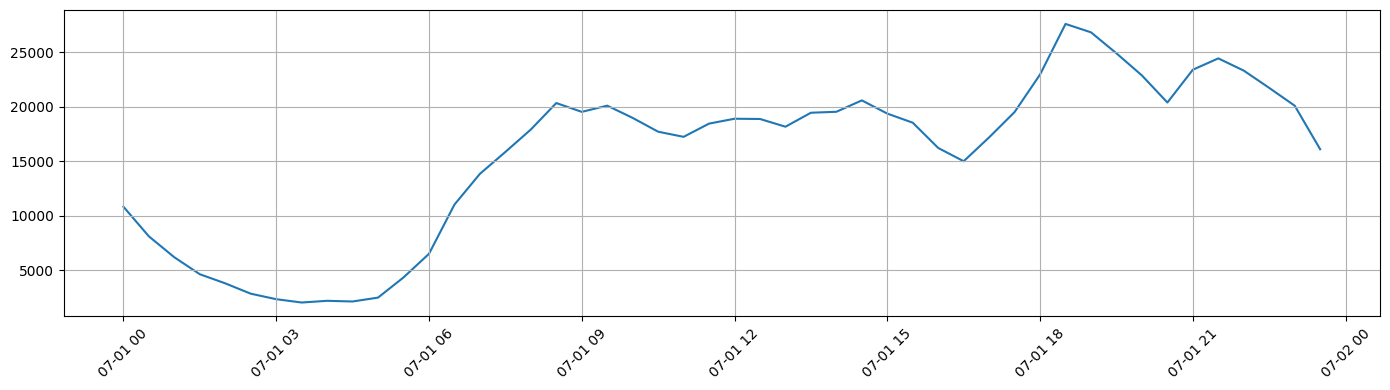

In [3]:
util.plot_series(data.iloc[:48], figsize=figsize)

* We wanted to take advantage of correlation between nearby points

## ...Then Forward Again

**But there is more! Let's look just a little bit further**

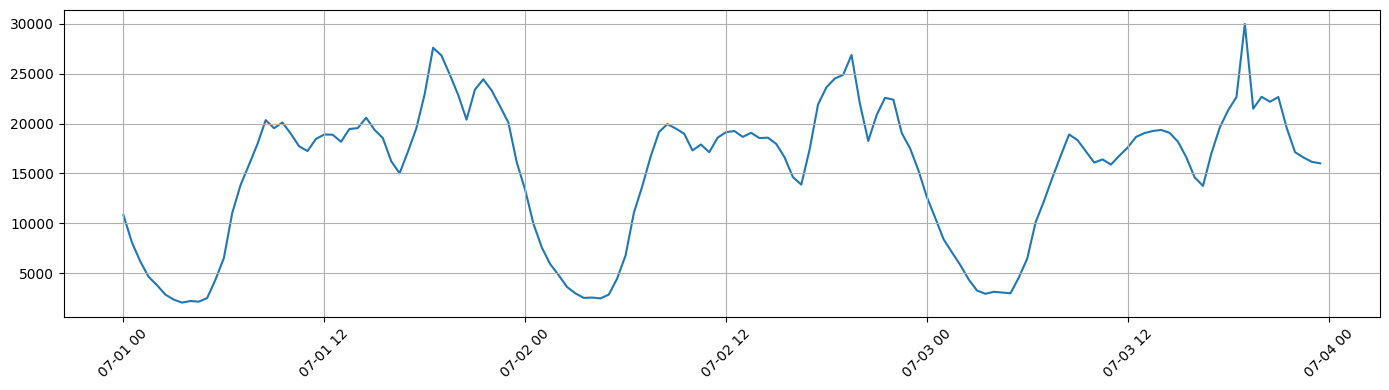

In [4]:
util.plot_series(data.iloc[:3*48], figsize=figsize)

* There is recurring pattern!
* I.e. the series is _approximately periodic_

## Determine the Period

**This is even clearer in the autocorrelation plot**

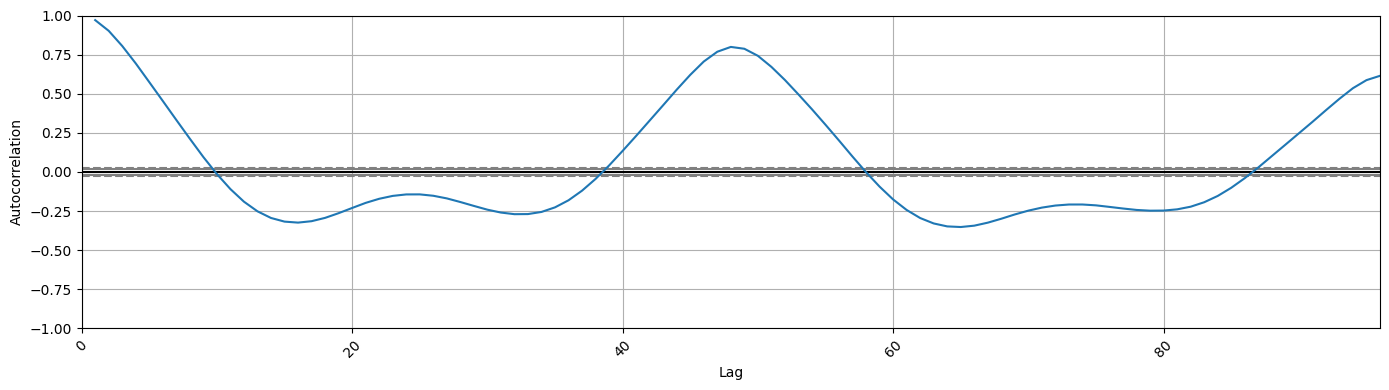

In [5]:
util.plot_autocorrelation(data, max_lag=96, figsize=figsize)

* There is _strong peak at 48_ time steps (a time step is 30 minutes)
* This is consistent with a period of 24 hours

## Reevaluate

**Let's recap our situation**

Our sequence-based estimator

* ...Is solving a uselessly complicated problem
* ...And it's not using all the available knowledge

> **These are both _very serious drawbacks_**

In any problem:

* _Never_ introduce complications unless they are worth it
* _Never_ willingly throw away information

<div class=big>Can we do something to tackle both problems?</div>

## Time as an Additional Input

**One way to look at that**

...Is that the distribution _depends on the time of the day_

* Therefore, we should consider the number of taxi calls $x$
* ...And the time of the day $t$ together

**Let us extract (from the index) the time information information:**

In [6]:
dayhour = (data.index.hour + data.index.minute / 60)

We can then add it as a separate column to the data:

In [7]:
data2 = data.copy()
data2['dayhour'] = dayhour

## Multivariate Distribution

**Let us examine the resulting multivariate distribution**

We can use a 2D histogram:

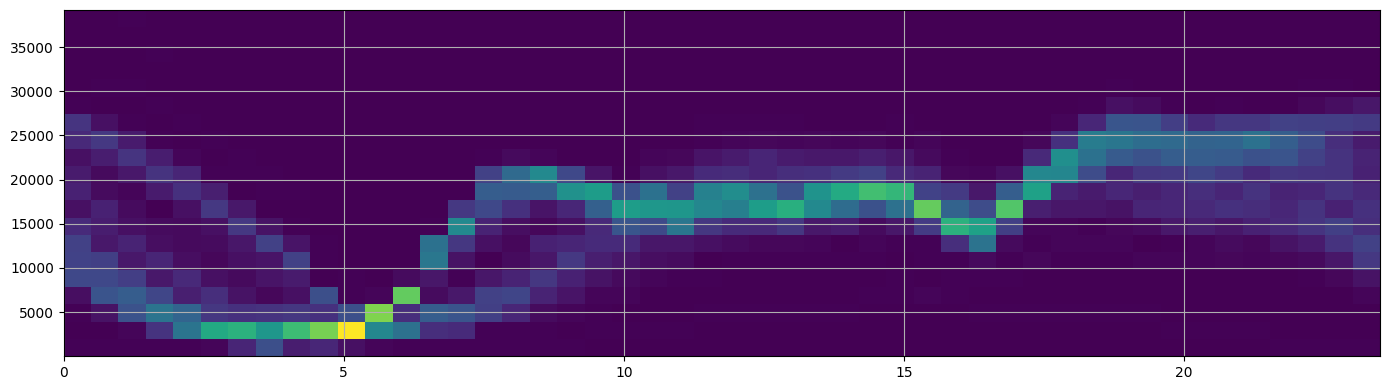

In [ ]:
util.plot_histogram2d(data2['dayhour'], data2['value'], bins=(48, 20), figsize=figsize)
#we interpret this graph as: the x are the hours of the day, and the y are the values. The color intensity indicates the frequency of occurrences for each (hour, value) pair.

* x = time, y = value, color = frequency of occurrence

## Anomaly Detection with Controlled Variables

**If we feed this information to KDE**

...We learn an estimator for the _joint_ PDF:

$$
f(t, x)
$$

...Which is not exactly what we were looking for

**Assume we flag an anomaly when $f(t, x) \leq \theta$**

* This may happen when $x$ (the number of cars) takes an unlikely value
* ...Or when $t$ (the time) does

**Except that the _time is completely predictable_**

* Any different in its estimated density is only due to sampling choices
* In practice, it's a _controlled variable_

## Anomaly Detection with Controlled Variables

**What we really care about is the _conditional density_, i.e.**

$$
f(x \mid t)
$$

* I.e. the density value of the observed value of $x$
* Assuming that the time $t$ is _known_

**Our true anomaly detection conditions should then be:**

$$
f(x \mid t) \leq \varepsilon
$$

...We know how to approximate only to the _joint_ density function $f(t, x)$

> **How to handle the conditioning variable?**

## Anomaly Detection with Controlled Variables

**There's more than one way to do it**

...The one we'll see starts with the definition of conditional probability:

$$
f(t, x) = f(x \mid t) f(t)
$$
where f(t,x) is the joint density function of t and x, i.e. the probability of observing the pair (t,x)

Meaning that we can detect anomalies by evaluating:

$$
\frac{f(t, x)}{f(t)} \leq \varepsilon
$$

**In order to pull this off, we need**

* An estimator for $f(t, x)$, which we already have (it is our multivariate KDE)
* An estimator for $f(t)$, which we can easily obtain (e.g. using KDE again)

**...But in our specific case, things are _even simpler_**

## Time Distribution

**In particular, the distribution of time values is uniform:**

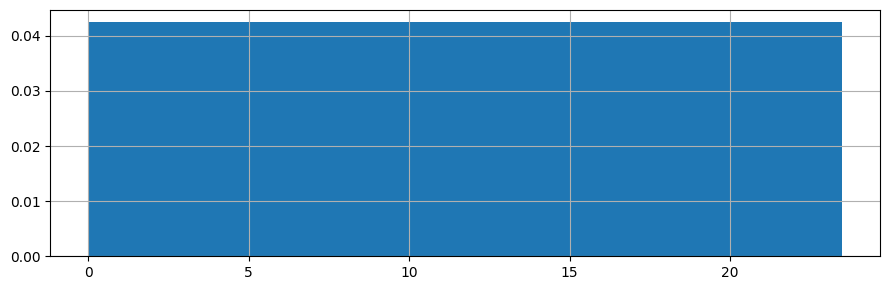

In [9]:
util.plot_histogram(data2['dayhour'], bins=48)

## Our Time-Dependent Estimator

**In non-degenerate cases, our condition can always be rewritten:**

$$
\frac{f(t, x)}{f(t)} \leq \varepsilon \quad \longrightarrow \quad f(t, x) \leq \varepsilon f(t)
$$

* But since $f(t)$ is constant this is equivalent to checking the joint probability
* ...With a modified threshold

$$
f(t, x) \leq \varepsilon^\prime
$$

* The threshold $\varepsilon^\prime$ now represents $\varepsilon f(t)$
* ...But since we still need to choose it value, it make little difference to us

**Hence, for this problem we can use $f(t, x)$ for anomaly detection**

## Choosing a Bandwidth

**We now need to pick a threshold**

* We can use grid search and cross-validation again
* ...But this time we need to make sure to _normalize the data_

In [10]:
scaler = MinMaxScaler()
data2_n_tr = data2[data2.index < train_end].copy()
data2_n_tr[:] = scaler.fit_transform(data2_n_tr)
data2_n = data2.copy()
data2_n[:] = scaler.transform(data2)

**This is due to a low-level technical detail:**

* scikit-learn uses a very efficient KDE implementation
* ...But it requires using _the same bandwidth_ for all input dimensions

Normalization makes this drawback less impactful

## Choosing a Bandwidth

**We can then optimize the bandwidth as usual**

We'll use cross-validation, since we have vector input

In [11]:
from sklearn.model_selection import GridSearchCV
params = {'bandwidth': np.linspace(0.001, 0.01, 10)}
opt = GridSearchCV(KernelDensity(kernel='gaussian'), params, cv=5)
opt.fit(data2_n_tr);
opt.best_params_

{'bandwidth': np.float64(0.006)}

* As another small advantage of normalization
* ...Choosing the grid search range becomes a bit easier

## Alarm Signal

**Let us obtain the alarm signal**

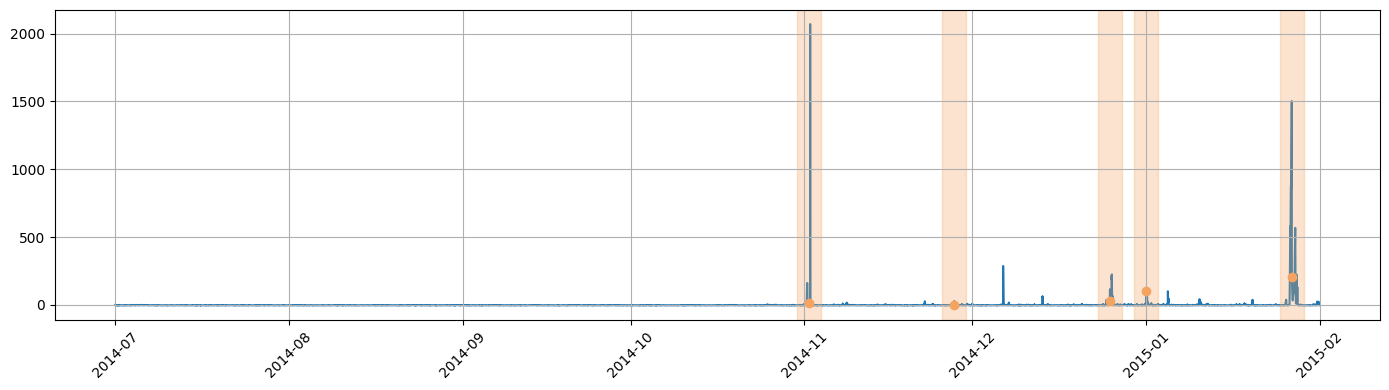

In [12]:
ldens2 = opt.score_samples(data2_n)
signal2 = pd.Series(index=data2.index, data=-ldens2)
util.plot_series(signal2, labels=labels, windows=windows, figsize=figsize)

## Threshold Optimization

**Now, let us optimize our threshold:**

In [13]:
signal2_opt = signal2[signal2.index < val_end]
labels_opt = labels[labels < val_end]
windows_opt = windows[windows['end'] < val_end]
thr2_range = np.linspace(10, 100, 100)
best_thr2, best_cost2 = util.opt_thr(signal2_opt, labels_opt, windows_opt, cmodel, thr2_range)
print(f'Best threshold: {best_thr2:.3f}, corresponding cost: {best_cost2:.3f}')

Best threshold: 27.273, corresponding cost: 9.000


On the whole dataset:

In [14]:
c2tst = cmodel.cost(signal2, labels, windows, best_thr2)
print(f'Cost on the whole dataset {c2tst}')

Cost on the whole dataset 18


* It was 45 for the first approach and 30 for the second

<div class=big>There is a second period in the data!<br>Can you guess which one?</div> Probably a weekly one? Or a yearly one?